In [12]:
pip install selenium webdriver-manager

Note: you may need to restart the kernel to use updated packages.


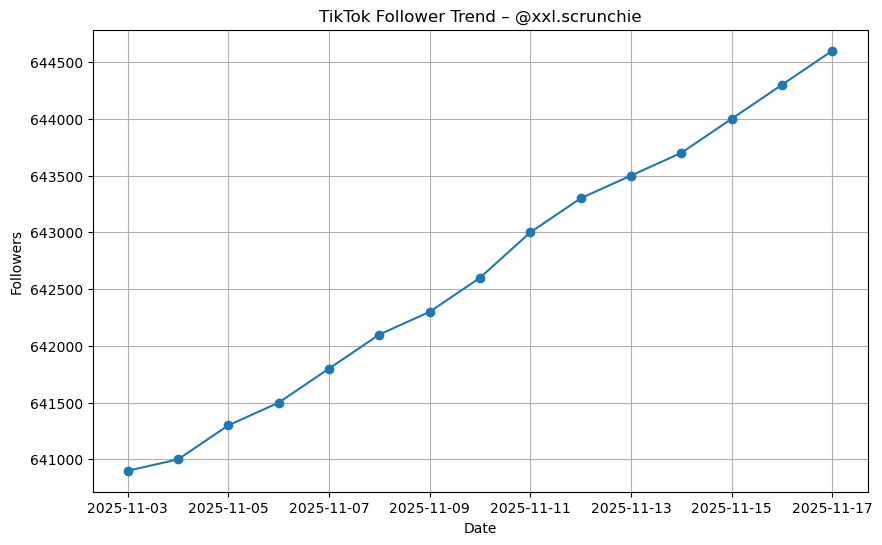

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
import json
import pandas as pd
import matplotlib.pyplot as plt

options = Options()
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument("--disable-infobars")
options.add_argument("--start-maximized")
options.add_experimental_option("excludeSwitches", ["enable-automation"])
options.add_experimental_option('useAutomationExtension', False)

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://socialblade.com/tiktok/user/xxl.scrunchie")

html = driver.page_source
driver.quit()

# Extract the NEXT_DATA JSON
start = html.find("__NEXT_DATA__")
json_start = html.find("{", start)
json_end = html.find("</script>", json_start)
json_str = html[json_start:json_end]
data = json.loads(json_str)

queries = []
if "trpcState" in data:
    queries = data["trpcState"]["json"]["queries"]
elif "props" in data and "pageProps" in data["props"] and "trpcState" in data["props"]["pageProps"]:
    queries = data["props"]["pageProps"]["trpcState"]["json"]["queries"]
elif "props" in data and "pageProps" in data["props"]:
    # fallback scan entire object for queries
    for v in data["props"]["pageProps"].values():
        if isinstance(v, dict) and "queries" in v:
            queries = v["queries"]

history_block = None
for q in queries:
    if q["queryKey"][0] == ["tiktok", "history"]:
        history_block = q
        break

if history_block is None:
    raise Exception("Could not find the TikTok history block.")

# Extract the daily stats
days = history_block["state"]["data"]

# Build DataFrame
df = pd.DataFrame(days)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# Plot
plt.figure(figsize=(10,6))
plt.plot(df["date"], df["followers"], marker="o")
plt.title("TikTok Follower Trend – @xxl.scrunchie")
plt.xlabel("Date")
plt.ylabel("Followers")
plt.grid(True)
plt.show()
